# Surgical PubMed corpus: descriptive statistics

This notebook summarizes the downloaded PubMed corpus before abstract cleaning and LLM concept extraction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# This works whether Jupyter was started in data/table or at the repository root.
candidate_paths = [
    Path("surgery.pubmed.works.csv"),
    Path("data/table/surgery.pubmed.works.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find surgery.pubmed.works.csv. "
        "Start Jupyter from the repository root or data/table."
    )

works = pd.read_csv(
    data_path,
    dtype={"pmid": "string", "doi": "string"},
    parse_dates=["publication_date"],
)
works["publication_year"] = pd.to_numeric(
    works["publication_year"], errors="coerce"
).astype("Int64")

print(f"Loaded {len(works):,} PubMed records from {data_path}.")
display(works.head())

Loaded 306,476 PubMed records from surgery.pubmed.works.csv.


,id,pmid,doi,display_name,publication_date,publication_year,abstract,source_id,modules,mesh_terms,publication_types,languages,is_retracted,elements,concepts
0,PMID:19037193,19037193,<NA>,Epidural analgesia and liver resection: postop...,2008-11-27,2008,BACKGROUND: The aim of this study was to quant...,Minerva anestesiologica,hpb_surgery,"Aged; Analgesia, Epidural; Anticoagulants; Blo...",Journal Article,eng,False,NaN,[]
1,PMID:19691985,19691985,10.1016/j.jss.2009.05.021,Safety of hepatic resection in metastatic dise...,2009-06-12,2009,BACKGROUND: Unresectable hepatic metastases fr...,The Journal of surgical research,hpb_surgery,"Adult; Carcinoma, Adenosquamous; Cholangiocarc...",Journal Article,eng,False,NaN,[]
2,PMID:19932902,19932902,10.1016/j.jss.2009.07.042,"""Anatomical"" versus ""territorial"" belonging of...",2009-08-27,2009,BACKGROUND: Venous drainage patterns are of vi...,The Journal of surgical research,hpb_surgery,"Adult; Anatomy, Regional; Female; Hepatectomy;...","Journal Article; Research Support, Non-U.S. Gov't",eng,False,NaN,[]
3,PMID:20036394,20036394,10.1016/j.jss.2009.09.001,Factors affecting number of lymph nodes harves...,2009-09-25,2009,BACKGROUND: Lymph node involvement is a highly...,The Journal of surgical research,colorectal_surgery,"Adult; Aged; Aged, 80 and over; Body Mass Inde...","Journal Article; Research Support, U.S. Gov't,...",eng,False,NaN,[]
4,PMID:19784713,19784713,10.1007/s11845-009-0422-5,Prophylactic colectomy for hyperplastic polypo...,2009-09-26,2009,BACKGROUND: Hyperplastic polyposis (HP) is imp...,Irish journal of medical science,colorectal_surgery,Colectomy; Colonic Neoplasms; Colonic Polyps; ...,Journal Article,eng,False,NaN,[]


In [2]:
doi = works["doi"].str.strip().replace("", pd.NA)
abstract_present = works["abstract"].fillna("").str.strip().ne("")
source_present = works["source_id"].fillna("").str.strip().ne("")
retracted = works["is_retracted"].astype(str).str.lower().eq("true")
module_labels = (
    works["modules"].fillna("").str.split(";").explode().str.strip()
)
module_labels = module_labels[module_labels.ne("")]
papers_in_multiple_modules = works["modules"].fillna("").str.count(";").gt(0).sum()

year_min = works["publication_year"].min()
year_max = works["publication_year"].max()
facts = pd.Series(
    {
        "PubMed records / articles": len(works),
        "Unique PMIDs / papers": works["pmid"].nunique(),
        "Unique DOIs": doi.nunique(),
        "Publication-year range": f"{year_min}–{year_max}",
        "Papers with a non-empty abstract": int(abstract_present.sum()),
        "Distinct journals / sources": works.loc[source_present, "source_id"].nunique(),
        "Module labels": module_labels.nunique(),
        "Papers assigned to multiple modules": int(papers_in_multiple_modules),
        "Retracted records": int(retracted.sum()),
    },
    name="value",
).to_frame()

display(facts)

,value
PubMed records / articles,306476
Unique PMIDs / papers,306476
Unique DOIs,298313
Publication-year range,2008–2026
Papers with a non-empty abstract,306476
Distinct journals / sources,4103
Module labels,9
Papers assigned to multiple modules,88864
Retracted records,0


In [3]:
module_counts = (
    module_labels.value_counts()
    .rename_axis("module")
    .rename("papers")
    .to_frame()
)

print("Paper counts by search module (one paper can belong to more than one module):")
display(module_counts)

Paper counts by search module (one paper can belong to more than one module):


,papers
module,
visceral_oncology,77690
core_surgery,61809
thoracic_surgery,60160
perioperative_biology_microbiome,59559
vascular_surgery,56958
complications_outcomes_prediction,34932
upper_gi_bariatric,34393
hpb_surgery,30653
colorectal_surgery,16603


,papers
publication_year,
2008,1
2009,5
2010,412
2011,3306
2012,8387
2013,16566
2014,20220
2015,20975
2016,21036


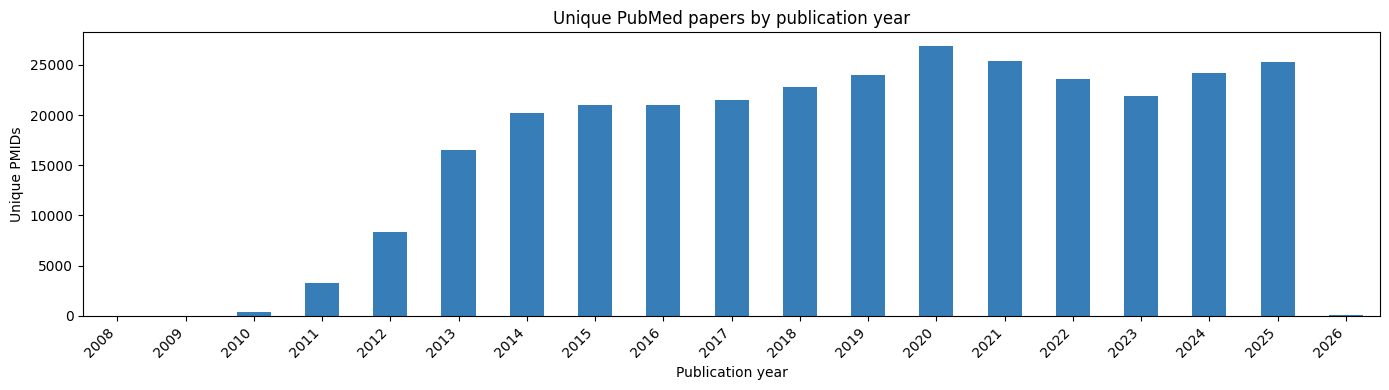

In [4]:
publications_by_year = (
    works.dropna(subset=["publication_year"])
    .groupby("publication_year")["pmid"]
    .nunique()
    .rename("papers")
    .to_frame()
    .sort_index()
)

display(publications_by_year)

ax = publications_by_year.plot(
    kind="bar",
    figsize=(14, 4),
    legend=False,
    color="#377eb8",
)
ax.set(
    title="Unique PubMed papers by publication year",
    xlabel="Publication year",
    ylabel="Unique PMIDs",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# LLM concepts from the first 20 records in the extracted-concept table.
# `nrows=20` avoids loading the complete (large) CSV merely for this inspection.
import json
from collections import Counter

llm_candidate_paths = [
    Path("surgery.pubmed.gpt-5-nano.llm.csv"),
    Path("data/table/surgery.pubmed.gpt-5-nano.llmcsv"),
]
llm_path = next((path for path in llm_candidate_paths if path.exists()), None)
if llm_path is None:
    raise FileNotFoundError(
        "Could not find surgery.pubmed.gpt-5-nano.v2.llm.csv. "
        "Run the concept-extraction command first."
    )

top_20_llm_papers = pd.read_csv(
    llm_path,
    nrows=50000,
    dtype={"id": "string", "pmid": "string", "llm_concepts": "string"},
)

def parse_llm_concepts(value):
    if pd.isna(value) or not str(value).strip():
        return []
    parsed = json.loads(value)
    if not isinstance(parsed, list) or not all(isinstance(item, str) for item in parsed):
        raise ValueError("Each llm_concepts value must be a JSON list of strings.")
    return parsed

top_20_llm_papers["rank"] = range(1, len(top_20_llm_papers) + 1)
top_20_llm_papers["extracted_concepts"] = top_20_llm_papers["llm_concepts"].map(
    parse_llm_concepts
)

paper_concepts = top_20_llm_papers[
    ["rank", "pmid", "display_name", "publication_date", "extracted_concepts"]
].rename(columns={"display_name": "title"})

print(f"Loaded concepts for the first {len(paper_concepts)} papers from {llm_path}.")
display(paper_concepts)

concepts_in_top_20 = [
    concept
    for concepts in top_20_llm_papers["extracted_concepts"]
    for concept in concepts
]
concept_frequency = (
    pd.DataFrame(Counter(concepts_in_top_20).items(), columns=["concept", "papers"])
    .sort_values(["papers", "concept"], ascending=[False, True])
    .reset_index(drop=True)
)

print(
    f"{len(concepts_in_top_20)} extracted concept instances; "
    f"{len(concept_frequency)} unique concepts."
)
display(concept_frequency)


Loaded concepts for the first 50000 papers from surgery.pubmed.gpt-5-nano.llm.csv.


,rank,pmid,title,publication_date,extracted_concepts
0,1,19037193,Epidural analgesia and liver resection: postop...,2008-11-27,"[postoperative coagulopathy, epidural catheter..."
1,2,19691985,Safety of hepatic resection in metastatic dise...,2009-06-12,"[unresectable hepatic metastases, yttrium-90 h..."
2,3,19932902,"""Anatomical"" versus ""territorial"" belonging of...",2009-08-27,"[live donor liver transplantation, middle hepa..."
3,4,20036394,Factors affecting number of lymph nodes harves...,2009-09-25,"[lymph node involvement, colorectal cancer sta..."
4,5,19784713,Prophylactic colectomy for hyperplastic polypo...,2009-09-26,"[hyperplastic polyposis, laparoscopic total co..."
...,...,...,...,...,...
49995,49996,26281277,Risk-Adjusted Staffing to Improve Patient Value.,2015-01-01,"[hospital-acquired conditions, catheter-acquir..."
49996,49997,26281327,The expression and clinical effects of alpha-m...,2015-01-01,"[alpha-methylacyl-coa racemase, malignant pleu..."
49997,49998,26282549,The Prognosis of Patients with Liver Metastase...,2015-01-01,"[liver metastases from colorectal cancer, radi..."
49998,49999,26285381,Care of the Patient Undergoing Radial Approach...,2015-01-01,"[coronary vascular disease, transradial cardia..."


316404 extracted concept instances; 132852 unique concepts.


,concept,papers
0,postoperative complications,1784
1,hepatocellular carcinoma,1358
2,disease-free survival,1221
3,bariatric surgery,938
4,body mass index,828
...,...,...
132847,≤ t1a lesions,1
132848,≤5th percentile,1
132849,≥ t1b lesions,1
132850,≥95th percentile,1


In [6]:
# Print every concept from the first 10 papers without table truncation.
from pathlib import Path
import json
import pandas as pd

candidate_paths = [
    Path("surgery.pubmed.gpt-5-nano.llm.csv"),
    Path("data/table/surgery.pubmed.gpt-5-nano.llm.csv"),
]
llm_path = next((path for path in candidate_paths if path.exists()), None)
if llm_path is None:
    raise FileNotFoundError("Could not find the LLM output CSV.")

first_ten = pd.read_csv(
    llm_path,
    nrows=10,
    usecols=["pmid", "llm_concepts"],
    dtype={"pmid": "string", "llm_concepts": "string"},
)

for rank, paper in enumerate(first_ten.itertuples(index=False), start=1):
    concepts = [] if pd.isna(paper.llm_concepts) else json.loads(paper.llm_concepts)
    print(f"\n{rank}. PMID {paper.pmid}")
    if concepts:
        for concept in concepts:
            print(f"  - {concept}")
    else:
        print("  - no concepts extracted")



1. PMID 19037193
  - postoperative coagulopathy
  - epidural catheter removal
  - major liver resection
  - platelet count
  - prothrombin time
  - activated partial thromboplastin time
  - international normalised ratio
  - vascular inflow occlusion

2. PMID 19691985
  - unresectable hepatic metastases
  - yttrium-90 hepatic arterial therapy
  - hepatic malignancies
  - surgical downstaging
  - response evaluation criteria in solid tumors
  - right hepatic lobectomy
  - left lateral hepatectomy
  - microwave ablation

3. PMID 19932902
  - live donor liver transplantation
  - middle hepatic vein
  - 3-d ct reconstructions
  - anatomical-topographical patterns
  - territorial-physiologic patterns
  - couinaud's anatomical variants
  - venous congestion

4. PMID 20036394
  - lymph node involvement
  - colorectal cancer staging
  - number of lymph nodes harvested
  - surgeon experience
  - pathologist experience

5. PMID 19784713
  - hyperplastic polyposis
  - laparoscopic total colectom